# Model Explainability - TreeSHAP for the Final XGBoost Model

The final XGBoost model using the Day-Anchored Lookback Strategy (trained on train+val, tuned lookback = 24h)
is the best performing model. This notebook makes it interpretable using TreeSHAP
: exact Shapley values for tree ensembles, providing local
explanations per hour that aggregate consistently into global feature importance.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import holidays
import shap
from sklearn.preprocessing import RobustScaler
from xgboost import XGBRegressor
from sklearn.isotonic import IsotonicRegression
import seaborn as sns

## Load Data & Rebuild the Pipeline (identical to `modelling.ipynb`)

In [3]:
# ---------- Load data ----------
data = pd.read_parquet("data/ENTSOE/entsoe_price_and_loadfc.parquet")
weather_fc = pd.read_parquet("data/NOAA GFS/weather_forecast.parquet")
data = data.join(weather_fc, how="left")

# ---------- Feature extraction (identical to modelling.ipynb) ----------
# lag features (naive timestamp manipulation to avoid issues with DST transitions)
idx_naive = data.index.tz_localize(None)
prev_naive_day = idx_naive - pd.DateOffset(days=1)
prev_naive_day2 = idx_naive - pd.DateOffset(days=2)
prev_naive_week = idx_naive - pd.DateOffset(weeks=1)

idx_prev_day = prev_naive_day.tz_localize("Europe/Berlin", ambiguous=False, nonexistent="shift_forward")
idx_prev_day2 = prev_naive_day2.tz_localize("Europe/Berlin", ambiguous=False, nonexistent="shift_forward")
idx_prev_week = prev_naive_week.tz_localize("Europe/Berlin", ambiguous=False, nonexistent="shift_forward")

data["price_lag_24h"] = data["da_price"].reindex(idx_prev_day).to_numpy()
data["price_lag_48h"] = data["da_price"].reindex(idx_prev_day2).to_numpy()
data["price_lag_168h"] = data["da_price"].reindex(idx_prev_week).to_numpy()

# calendar features in local delivery time
data["weekday_sin"] = np.sin(2 * np.pi * data.index.dayofweek / 7)
data["weekday_cos"] = np.cos(2 * np.pi * data.index.dayofweek / 7)
data["hour_sin"] = np.sin(2 * np.pi * data.index.hour / 24)
data["hour_cos"] = np.cos(2 * np.pi * data.index.hour / 24)

ger_holidays = list(holidays.Germany(years=data.index.year.unique()))
ger_holidays = pd.to_datetime(ger_holidays).tz_localize(data.index.tz)
data["holiday_not_sunday"] = (data.index.normalize().isin(ger_holidays) & (data.index.dayofweek != 6))

data = data["2023":"2025"]

# ---------- Constants (identical to modelling.ipynb) ----------
LOCAL_TZ = "Europe/Berlin"
TRAIN_START = pd.Timestamp("2023-01-01", tz=LOCAL_TZ)
VAL_END     = pd.Timestamp("2025-07-01", tz=LOCAL_TZ)   # train+val = TRAIN_START .. VAL_END
TEST_START  = pd.Timestamp("2025-07-01", tz=LOCAL_TZ)
TEST_END    = pd.Timestamp("2026-01-01", tz=LOCAL_TZ)

TARGET_COL = "da_price"
FEATURE_COLS = [
    "load_fc", "ssrd_fc", "U100_fc",
    "price_lag_24h", "price_lag_48h", "price_lag_168h",
    "weekday_sin", "weekday_cos", "hour_sin", "hour_cos", "holiday_not_sunday",
]  # final feature set after feature selection in modelling.ipynb
LAG_COLS = [col for col in FEATURE_COLS if col.startswith("price_lag")]
SCALE_COLS = ["load_fc", "price_lag_24h", "price_lag_48h", "price_lag_168h", "ssrd_fc", "U100_fc"]
SEQUENCE_COLS = [TARGET_COL]
XGB_LOOKBACK = 24   # tuned lookback of the final model

model_df = data[[TARGET_COL] + FEATURE_COLS].copy()

# helper functions for transformation and error calculation
def asinh_transform(y, c):
    return np.arcsinh(y / c)

def asinh_inverse(y_t, c):
    return c * np.sinh(y_t)

def mae_score(y_true, y_pred) -> float:
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

def rmse_score(y_true, y_pred) -> float:
    return float(np.sqrt(np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)))

In [4]:
# ---------- Stage-2 preprocessing: c and scaler fitted on RAW train+val ----------
trainval_df = model_df.loc[(model_df.index >= TRAIN_START) & (model_df.index < VAL_END)].copy()
c_tv = np.median(np.abs(trainval_df[TARGET_COL]))
for col in [TARGET_COL] + LAG_COLS:
    trainval_df[col] = asinh_transform(trainval_df[col], c_tv)
scaler_tv = RobustScaler()
trainval_df[SCALE_COLS] = scaler_tv.fit_transform(trainval_df[SCALE_COLS])
print(f"c_tv = {c_tv:.4f}")

# ---------- Test window (history buffer + test period), stage-2 preprocessing ----------
test_win = model_df.loc[
    (model_df.index >= TEST_START - pd.Timedelta(hours=XGB_LOOKBACK)) & (model_df.index < TEST_END)
].copy()
y_test = test_win.loc[test_win.index >= TEST_START, TARGET_COL].to_numpy(dtype=np.float32)  # raw EUR/MWh
for col in [TARGET_COL] + LAG_COLS:
    test_win[col] = asinh_transform(test_win[col], c_tv)
test_win[SCALE_COLS] = scaler_tv.transform(test_win[SCALE_COLS])

# ---------- Day-Anchored Lookback Strategy builder (identical to modelling.ipynb) ----------
def _date_ints_from_index(index: pd.DatetimeIndex) -> np.ndarray:
    return np.array(
        [ts.year * 10000 + ts.month * 100 + ts.day for ts in index],
        dtype=np.int32,
    )

def build_anchored_dataset(df, sequence_cols, exog_cols, target_col, lookback_hours):
    """
    For each target timestamp in local delivery day D, the lookback window covers
    the rows ending immediately before D starts (same day-anchored history window for all
    hours of the same delivery day, DST-safe).
    """
    idx = df.index
    sequence_values = df[sequence_cols].to_numpy(dtype=np.float32)
    exog_values = df[exog_cols].to_numpy(dtype=np.float32)
    target_values = df[target_col].to_numpy(dtype=np.float32)
    date_ints = _date_ints_from_index(idx)

    first_pos_by_date = {}
    for pos, date_int in enumerate(date_ints):
        first_pos_by_date.setdefault(date_int, pos)

    X_seq, X_exog, y_target, ts_target = [], [], [], []
    for row_idx in range(len(df)):
        day_start_pos = first_pos_by_date[date_ints[row_idx]]
        keep_idx = np.arange(day_start_pos - lookback_hours, day_start_pos)
        if keep_idx[0] < 0:
            continue
        X_seq.append(sequence_values[keep_idx, :])
        X_exog.append(exog_values[row_idx])
        y_target.append(target_values[row_idx])
        ts_target.append(idx[row_idx])

    return (
        np.stack(X_seq),
        np.stack(X_exog),
        np.asarray(y_target, dtype=np.float32),
        pd.DatetimeIndex(ts_target),
    )

seq, exog, _, ts = build_anchored_dataset(test_win, SEQUENCE_COLS, FEATURE_COLS, TARGET_COL, XGB_LOOKBACK)
keep = ts >= TEST_START
seq, exog, ts_test = seq[keep], exog[keep], ts[keep]

# flat input as a DataFrame with readable feature names:
# window position "price_h-k" = asinh price k hours before the start of the delivery day
window_names = [f"price_h-{XGB_LOOKBACK - i}" for i in range(XGB_LOOKBACK)]
feature_names = window_names + FEATURE_COLS
X_test = pd.DataFrame(
    np.concatenate([seq.reshape(seq.shape[0], -1), exog], axis=1),
    columns=feature_names,
    index=ts_test,
)
print("X_test:", X_test.shape, "\ny_test:", y_test.shape)

c_tv = 90.2800
X_test: (4417, 35) 
y_test: (4417,)


In [5]:
# ---------- Load the final model + sanity checks ----------
xgb_anchored_final = XGBRegressor()
xgb_anchored_final.load_model("models/xgb_anchored_final.ubj")

assert xgb_anchored_final.n_features_in_ == X_test.shape[1], (
    f"feature mismatch: model expects {xgb_anchored_final.n_features_in_}, data has {X_test.shape[1]}"
)

y_pred = asinh_inverse(xgb_anchored_final.predict(X_test.to_numpy(dtype=np.float32)), c_tv)
print(f"Reproduced test scores: MAE={mae_score(y_test, y_pred):.4f}  RMSE={rmse_score(y_test, y_pred):.4f}")

Reproduced test scores: MAE=13.4636  RMSE=22.5130


## TreeSHAP

In [6]:
explainer = shap.TreeExplainer(xgb_anchored_final)   # tree_path_dependent (exact, no background data)
sv = explainer(X_test)                      # Explanation object (values, base_values, data)

# additivity check: base + sum(SHAP) must equal the model output (asinh scale)
pred_t = xgb_anchored_final.predict(X_test.to_numpy(dtype=np.float32))
recon = np.ravel(sv.base_values) + sv.values.sum(axis=1)
print("max |base + sum(SHAP) - prediction| =", float(np.abs(recon - pred_t).max()))
print(f"base value (expected asinh price) = {float(np.ravel(sv.base_values)[0]):.4f}")

max |base + sum(SHAP) - prediction| = 2.9802322387695312e-06
base value (expected asinh price) = 0.8126


In [7]:
# ---------- Collapse cyclic pairs (hour_sin/cos, weekday_sin/cos) into one feature each ----------
# SHAP is additive, so the combined contribution of a cyclic pair is the SUM of its two
# SHAP values (per instance). Additivity is preserved: base + sum stays the prediction
# (asinh scale). The data column for the merged feature is the ACTUAL value
# (hour 0-23, weekday 0-6) so beeswarm/dependence colour and axis are meaningful.
cyclic_pairs = {
    "hour":    ("hour_sin", "hour_cos", np.asarray(ts_test.hour, dtype=float)),
    "weekday": ("weekday_sin", "weekday_cos", np.asarray(ts_test.dayofweek, dtype=float)),
}
drop = {c for a, b, _ in cyclic_pairs.values() for c in (a, b)}

keep_cols = [f for f in feature_names if f not in drop]
keep_idx = [feature_names.index(f) for f in keep_cols]
collapsed_names = keep_cols + list(cyclic_pairs)

vals = [sv.values[:, keep_idx]]
dat  = [X_test.iloc[:, keep_idx].to_numpy()]
for name, (a, b, actual) in cyclic_pairs.items():
    ia, ib = feature_names.index(a), feature_names.index(b)
    vals.append((sv.values[:, ia] + sv.values[:, ib])[:, None])   # summed SHAP (net contribution)
    dat.append(actual[:, None])                                   # actual hour / weekday
collapsed_vals = np.concatenate(vals, axis=1)
collapsed_data = np.concatenate(dat, axis=1)
abs_c = np.abs(collapsed_vals)

sv_c = shap.Explanation(
    values=collapsed_vals,
    base_values=sv.base_values,
    data=collapsed_data,
    feature_names=collapsed_names,
)

# additivity preserved (only regrouped): base + sum(collapsed) == prediction (asinh scale)
recon_c = np.ravel(sv_c.base_values) + collapsed_vals.sum(axis=1)
print("max |base + sum(collapsed SHAP) - prediction| =", float(np.abs(recon_c - pred_t).max()))
print(f"collapsed features: {len(collapsed_names)} (was {len(feature_names)})")


max |base + sum(collapsed SHAP) - prediction| = 2.9802322387695312e-06
collapsed features: 33 (was 35)


### Global feature importance

The aggregated view sums the 24 price-history window positions into one bar so that the window can be compared with the named features. The beeswarm subsequently shows the direction and distribution of the attributions.

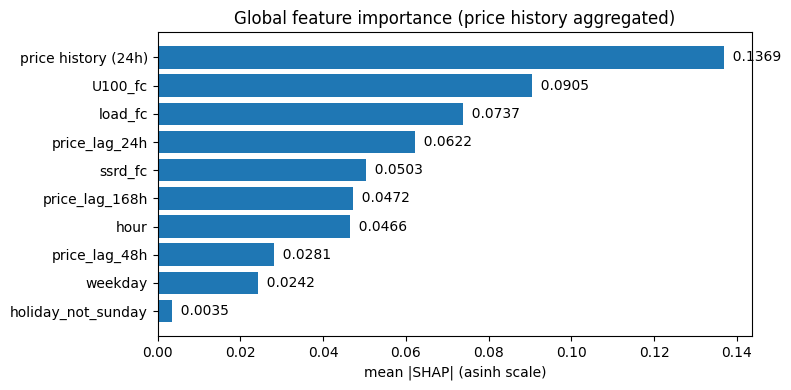

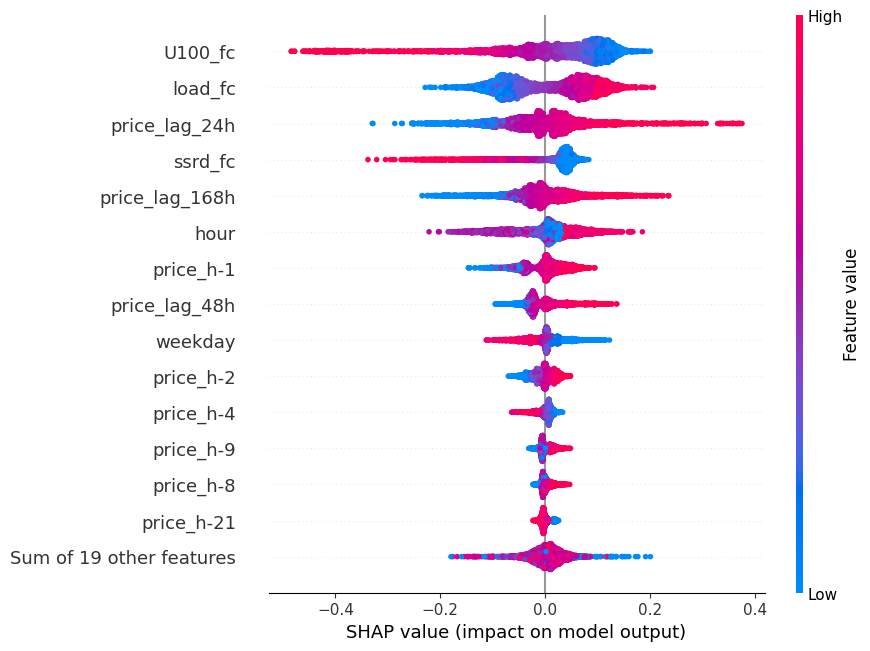

,feature,min,max,range,std,p2.5,p97.5,central_95_width
26,U100_fc,-0.4846,0.2010,0.6857,0.1205,-0.3904,0.1412,0.5315
27,price_lag_24h,-0.3297,0.3757,0.7054,0.0858,-0.1854,0.1859,0.3713
29,price_lag_168h,-0.2346,0.2359,0.4705,0.0654,-0.1556,0.1424,0.2980
24,load_fc,-0.2288,0.2071,0.4359,0.0815,-0.1300,0.1340,0.2640
25,ssrd_fc,-0.3379,0.0835,0.4214,0.0640,-0.1897,0.0597,0.2494


In [11]:
# ---------- Global importance ----------
# mean |SHAP| per feature (asinh scale). The 24 price-history window hours are summed
# into ONE bar (total contribution) so it is comparable to the individual named features.
win_idx  = [collapsed_names.index(w) for w in window_names]
exo_names = [f for f in collapsed_names if f not in window_names]

agg = {f"price history ({XGB_LOOKBACK}h)": np.abs(sv_c.values[:, win_idx]).sum(axis=1).mean()}
for f in exo_names:
    agg[f] = np.abs(sv_c.values[:, collapsed_names.index(f)]).mean()
agg = pd.Series(agg).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(agg.index, agg.values, color="tab:blue")
for i, v in enumerate(agg.values):
    ax.text(v, i, f"  {v:.4f}", va="center")
ax.set_xlabel("mean |SHAP| (asinh scale)")
ax.set_title("Global feature importance (price history aggregated)")
plt.tight_layout()
plt.show()

# ---------- Beeswarm: distribution and direction of the effects ----------
shap.plots.beeswarm(sv_c, max_display=15)

features = list(collapsed_names)

rows = []

for feature in features:
    j = collapsed_names.index(feature)
    values = sv_c.values[:, j]

    q025, q975 = np.quantile(values, [0.025, 0.975])

    rows.append({
        "feature": feature,
        "min": values.min(),
        "max": values.max(),
        "range": np.ptp(values),
        "std": values.std(ddof=1),
        "p2.5": q025,
        "p97.5": q975,
        "central_95_width": q975 - q025,
    })

dispersion_table = (
    pd.DataFrame(rows)
    .sort_values("central_95_width", ascending=False)
    .round(4)
)

display(dispersion_table.head(5))

Global importance (price history aggregated)
- Wind (`U100`) is the strongest single driver: one feature almost matches the entire 24 h price window, which is a sum over 24 features.
- The three explicit same-hour lags together (0.1375) and the full window (0.1369) have almost identical global importance.
- The weekly lag (168 h; 0.0472) is more important than the 2-day lag (48 h; 0.0281), consistent with the weekly peak seen in the ACF during the EDA.
- `holiday_not_sunday` has a very low value, but mean |SHAP| averages over all test hours and therefore dilutes rare events (~10 days per year). Its attribution is therefore examined separately at the daily level.

Beeswarm
- High wind and high solar radiation are associated with negative SHAP values, consistent with the merit-order effect. Both relationships are asymmetric.
- High load forecasts and high previous prices are associated with positive SHAP values.
- Temporal features generally have lower SHAP magnitudes than the other feature categories.
- Counterintuitive pattern for price history window h-4 and h-21

#### Check price history window h-4 and h-21

,feature,delivery_hour,n,spearman,low_price_mean_shap,high_price_mean_shap,high_minus_low_shap
0,price_h-4,0,184,-0.8239,0.0076,-0.0101,-0.0177
1,price_h-4,1,184,-0.7843,0.0069,-0.0099,-0.0168
2,price_h-4,2,185,-0.7946,0.0076,-0.0098,-0.0174
3,price_h-4,3,184,-0.8045,0.0076,-0.0106,-0.0182
4,price_h-4,4,184,-0.7987,0.0077,-0.0107,-0.0184
5,price_h-4,5,184,-0.8219,0.0083,-0.0106,-0.0189
6,price_h-4,6,184,-0.8604,0.0100,-0.0118,-0.0218
7,price_h-4,7,184,-0.8874,0.0110,-0.0133,-0.0243
8,price_h-4,8,184,-0.8934,0.0114,-0.0137,-0.0251
9,price_h-4,9,184,-0.9094,0.0123,-0.0143,-0.0266


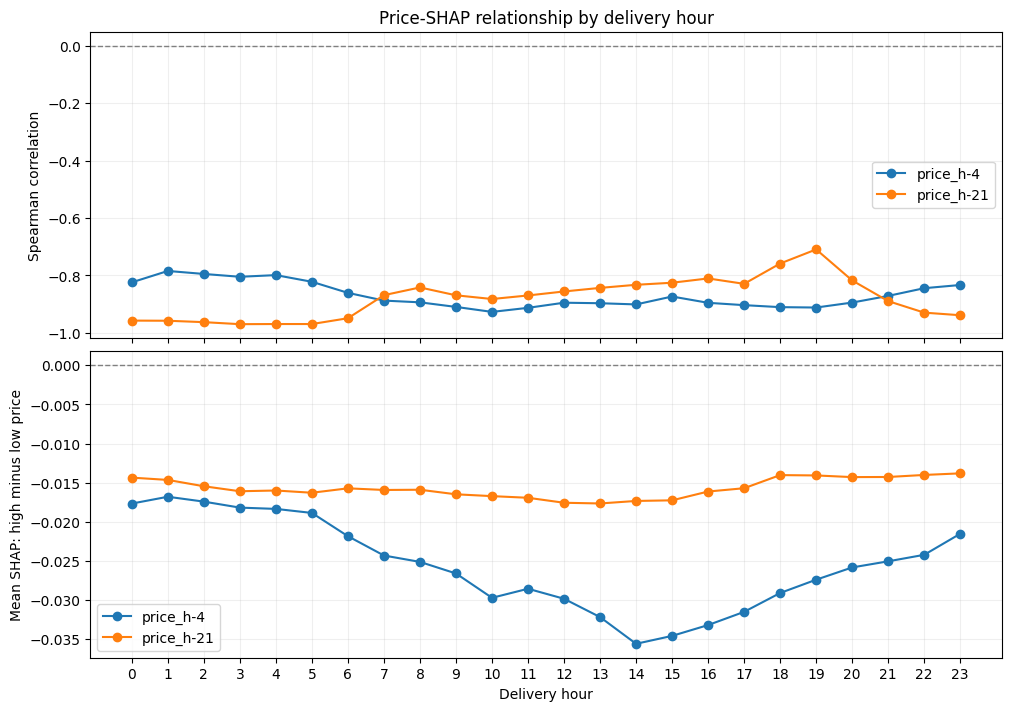

In [9]:
CHECK_FEATURES = ["price_h-4", "price_h-21"]
delivery_hours = np.asarray(ts_test.hour)

hourly_rows = []
feature_arrays = {}

for feature in CHECK_FEATURES:
    j = collapsed_names.index(feature)

    # Window prices are asinh-transformed, but not robust-scaled.
    price_raw = asinh_inverse(
        np.asarray(sv_c.data[:, j], dtype=float),
        c_tv,
    )
    shap_values_feature = np.asarray(sv_c.values[:, j], dtype=float)

    feature_arrays[feature] = (price_raw, shap_values_feature)

    for hour in range(24):
        mask = delivery_hours == hour
        x = price_raw[mask]
        y = shap_values_feature[mask]

        q25, q75 = np.quantile(x, [0.25, 0.75])

        # Spearman correlation
        spearman = (
            pd.Series(x).rank().corr(pd.Series(y).rank())
        )

        low_mean = y[x <= q25].mean()
        high_mean = y[x >= q75].mean()

        hourly_rows.append({
            "feature": feature,
            "delivery_hour": hour,
            "n": len(x),
            "spearman": spearman,
            "low_price_mean_shap": low_mean,
            "high_price_mean_shap": high_mean,
            "high_minus_low_shap": high_mean - low_mean,
        })

hourly_check = pd.DataFrame(hourly_rows)

display(
    hourly_check.round(4)
)

fig, axes = plt.subplots(
    2, 1,
    figsize=(10, 7),
    sharex=True,
    constrained_layout=True,
)

for feature in CHECK_FEATURES:
    values = hourly_check[hourly_check["feature"] == feature]

    axes[0].plot(
        values["delivery_hour"],
        values["spearman"],
        marker="o",
        label=feature,
    )
    axes[1].plot(
        values["delivery_hour"],
        values["high_minus_low_shap"],
        marker="o",
        label=feature,
    )

for ax in axes:
    ax.axhline(0, color="gray", linestyle="--", linewidth=1)
    ax.grid(alpha=0.2)
    ax.legend()

axes[0].set_ylabel("Spearman correlation")
axes[0].set_title("Price-SHAP relationship by delivery hour")

axes[1].set_ylabel("Mean SHAP: high minus low price")
axes[1].set_xlabel("Delivery hour")
axes[1].set_xticks(range(24))

plt.show()

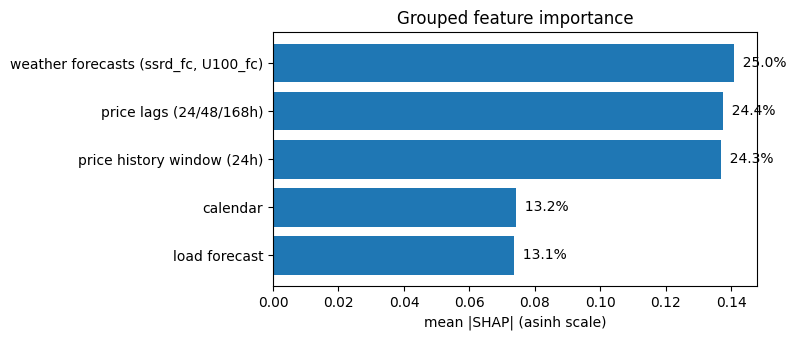

,group,mean_abs_shap,share_pct
0,"weather forecasts (ssrd_fc, U100_fc)",0.140777,24.998077
1,price lags (24/48/168h),0.137474,24.411451
2,price history window (24h),0.136861,24.302614
3,calendar,0.074328,13.198483
4,load forecast,0.073713,13.089371


In [10]:
# ---------- Grouped importance (on the collapsed features) ----------
# hour/weekday are already the NET (|sum|) contribution of their sin/cos pair.
groups = {
    f"price history window ({XGB_LOOKBACK}h)": window_names,
    "price lags (24/48/168h)": LAG_COLS,
    "load forecast": ["load_fc"],
    "weather forecasts (ssrd_fc, U100_fc)": ["ssrd_fc", "U100_fc"],
    "calendar": ["hour", "weekday", "holiday_not_sunday"],
}

rows = []
for name, cols in groups.items():
    idx = [collapsed_names.index(c) for c in cols]
    rows.append({"group": name, "mean_abs_shap": abs_c[:, idx].sum(axis=1).mean()})
group_df = pd.DataFrame(rows).sort_values("mean_abs_shap", ascending=True, ignore_index=True)
group_df["share_pct"] = 100 * group_df["mean_abs_shap"] / group_df["mean_abs_shap"].sum()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(group_df["group"], group_df["mean_abs_shap"])
for i, (v, p) in enumerate(zip(group_df["mean_abs_shap"], group_df["share_pct"])):
    ax.text(v, i, f"  {p:.1f}%", va="center")
ax.set_xlabel("mean |SHAP| (asinh scale)")
ax.set_title("Grouped feature importance")
plt.tight_layout()
plt.show()

display(group_df.sort_values("mean_abs_shap", ascending=False, ignore_index=True))

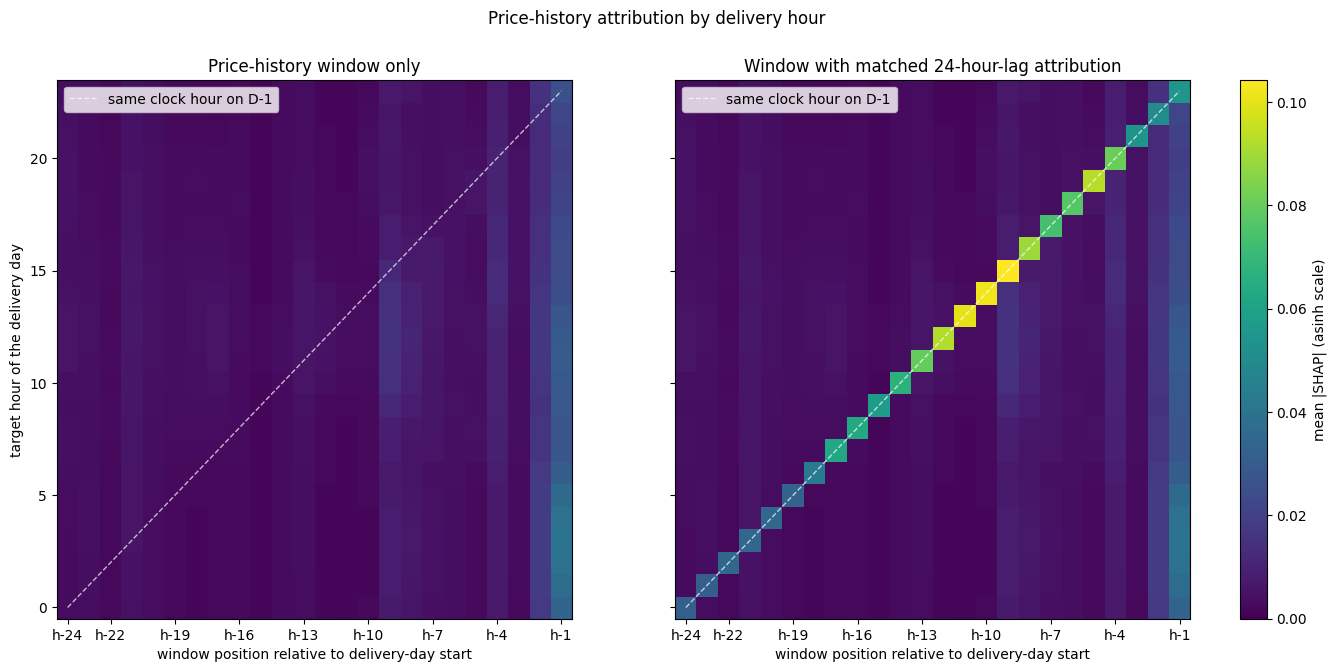

,information,mean_abs_shap,share_of_price_history_pct
0,price-history window (24 values),0.136861,49.888290
1,"price_lag_24h (D-1, same hour)",0.062151,22.654989
2,"price_lag_48h (D-2, same hour)",0.028114,10.248112
3,"price_lag_168h (D-7, same hour)",0.047209,17.208609


In [11]:
# ---------- Window position x target hour ----------
# The window ends immediately before the delivery day starts.
win_idx_c = [collapsed_names.index(w) for w in window_names]
target_hour = np.asarray(ts_test.hour)
lag24_idx = collapsed_names.index("price_lag_24h")

heat = np.zeros((24, XGB_LOOKBACK))
heat_comb = np.zeros((24, XGB_LOOKBACK))
same_hour_positions = []

for h in range(24):
    mask = target_hour == h
    if not mask.any():
        continue
    win_vals = sv_c.values[np.ix_(mask, win_idx_c)]
    heat[h] = np.abs(win_vals).mean(axis=0)
    combined = win_vals.copy()

    # D-1 at target hour h is in the window only if this position is available.
    same_hour_pos = XGB_LOOKBACK - 24 + h
    if 0 <= same_hour_pos < XGB_LOOKBACK:
        combined[:, same_hour_pos] += sv_c.values[mask, lag24_idx]
        same_hour_positions.append((same_hour_pos, h))
    heat_comb[h] = np.abs(combined).mean(axis=0)

vmax = max(heat.max(), heat_comb.max())
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)
for ax, matrix, title in [
    (axes[0], heat, "Price-history window only"),
    (axes[1], heat_comb, "Window with matched 24-hour-lag attribution"),
]:
    im = ax.imshow(
        matrix, aspect="auto", cmap="viridis", origin="lower", vmin=0, vmax=vmax
    )
    if same_hour_positions:
        positions, hours = zip(*same_hour_positions)
        ax.plot(
            positions,
            hours,
            "w--",
            lw=1,
            alpha=0.7,
            label="same clock hour on D-1",
        )
        ax.legend(loc="upper left")
    tick_pos = np.unique(
        np.linspace(0, XGB_LOOKBACK - 1, min(XGB_LOOKBACK, 9), dtype=int)
    )
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([f"h-{XGB_LOOKBACK - pos}" for pos in tick_pos])
    ax.set_xlabel("window position relative to delivery-day start")
    ax.set_title(title)

axes[0].set_ylabel("target hour of the delivery day")
fig.colorbar(
    im,
    ax=axes,
    label="mean |SHAP| (asinh scale)",
    fraction=0.046,
    pad=0.04,
)
fig.suptitle("Price-history attribution by delivery hour")
plt.show()

lag_rows = [
    {
        "information": f"price-history window ({XGB_LOOKBACK} values)",
        "mean_abs_shap": np.abs(sv_c.values[:, win_idx_c]).sum(axis=1).mean(),
    },
    {
        "information": "price_lag_24h (D-1, same hour)",
        "mean_abs_shap": np.abs(
            sv_c.values[:, collapsed_names.index("price_lag_24h")]
        ).mean(),
    },
    {
        "information": "price_lag_48h (D-2, same hour)",
        "mean_abs_shap": np.abs(
            sv_c.values[:, collapsed_names.index("price_lag_48h")]
        ).mean(),
    },
    {
        "information": "price_lag_168h (D-7, same hour)",
        "mean_abs_shap": np.abs(
            sv_c.values[:, collapsed_names.index("price_lag_168h")]
        ).mean(),
    },
]
lag_df = pd.DataFrame(lag_rows)
lag_df["share_of_price_history_pct"] = (
    100 * lag_df["mean_abs_shap"] / lag_df["mean_abs_shap"].sum()
)
display(lag_df)


Left plot (window only)
- Almost no diagonal pattern is visible.
- Reason: the feature `price_lag_24h` carries the exact same "same hour yesterday" value as the window diagonal, so TreeSHAP splits the credit and drains it away from the window.
- The latest window hour (h-1) has by far the highest SHAP values across almost all target hours.
- The second-latest hour (h-2) and the hours around 16:00 of the previous day are the next most important.
- No other striking patterns; importance is fairly stable across the different target hours.

Right plot (window + price_lag_24h added onto the diagonal)
- A clear diagonal pattern appears once the twin feature is merged back in.
- This indicates that the model relies on the combined same-hour information from the window and `price_lag_24h`; in the left plot, their correlation distributes the attribution across the two features.
- `price_lag_24h` matters more around midday and clearly less at night.

#### Dependence Plots

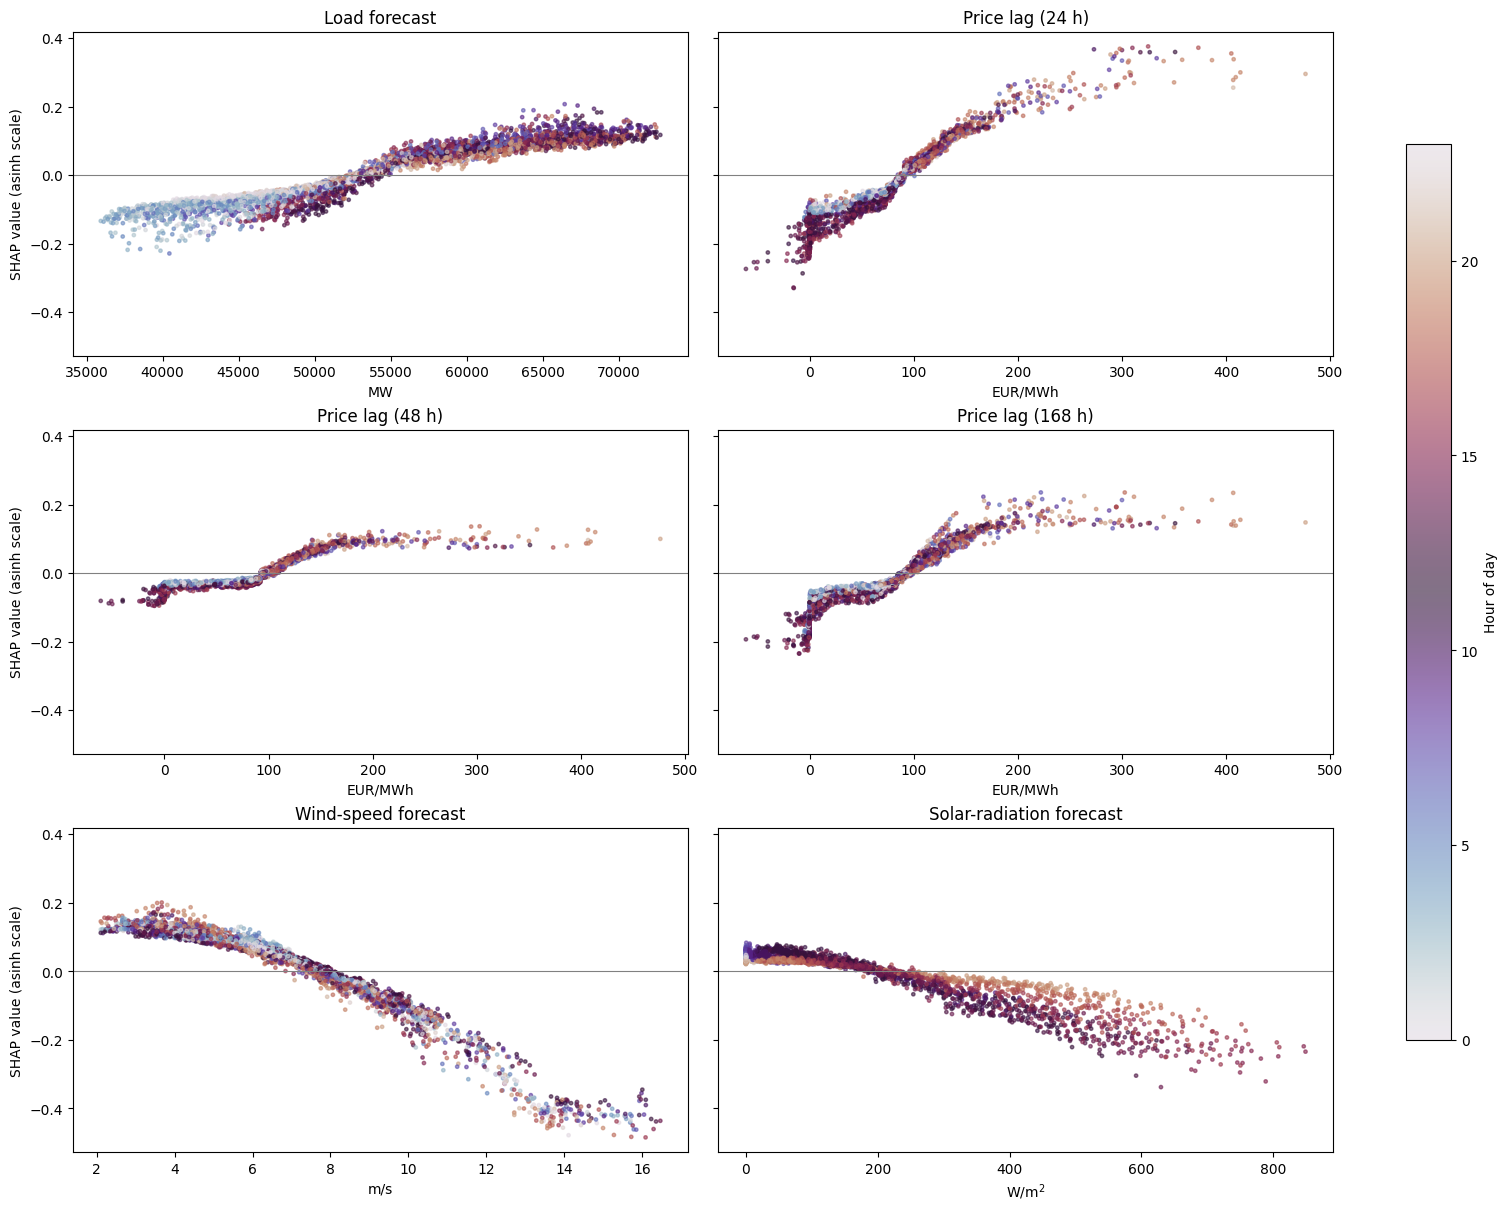

Median day-ahead price in Train+Validation: 90.16 EUR/MWh
price_lag_24h: zero crossing = 90.86 EUR/MWh, difference from median = +0.70 EUR/MWh
price_lag_48h: zero crossing = 97.14 EUR/MWh, difference from median = +6.98 EUR/MWh
price_lag_168h: zero crossing = 92.16 EUR/MWh, difference from median = +2.00 EUR/MWh


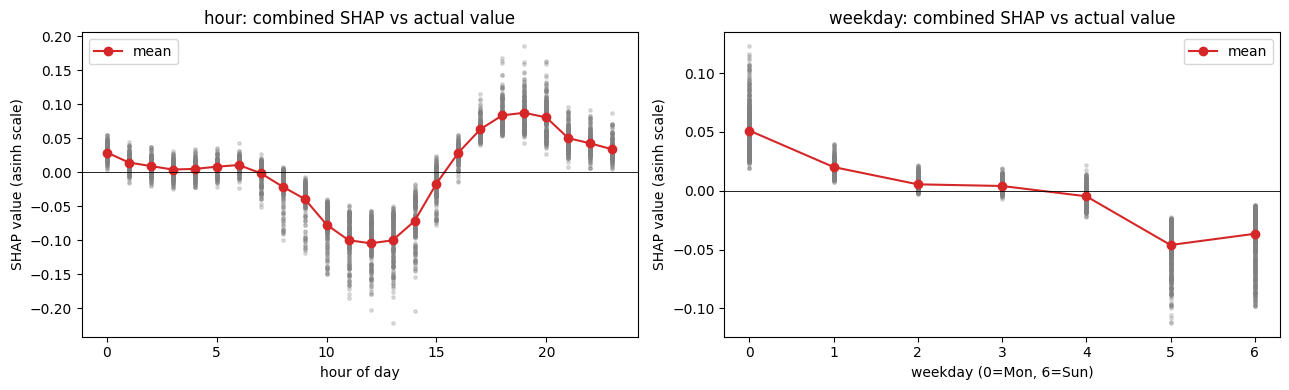

--- hour ---
      mean     std
g                 
0   0.0292  0.0107
1   0.0145  0.0111
2   0.0093  0.0112
3   0.0042  0.0107
4   0.0051  0.0113
5   0.0083  0.0100
6   0.0108  0.0098
7  -0.0012  0.0155
8  -0.0211  0.0244
9  -0.0390  0.0250
10 -0.0769  0.0276
11 -0.0997  0.0311
12 -0.1043  0.0310
13 -0.1000  0.0324
14 -0.0717  0.0338
15 -0.0165  0.0250
16  0.0291  0.0125
17  0.0635  0.0144
18  0.0839  0.0221
19  0.0877  0.0246
20  0.0808  0.0271
21  0.0503  0.0170
22  0.0427  0.0162
23  0.0339  0.0142

--- weekday ---
     mean     std
g                
0  0.0511  0.0186
1  0.0201  0.0056
2  0.0055  0.0045
3  0.0041  0.0039
4 -0.0047  0.0065
5 -0.0461  0.0172
6 -0.0366  0.0215



In [17]:
# Custom dependence plots:
# original feature values on the x-axis, SHAP values on the transformed output scale
hour = np.asarray(ts_test.hour)

dep_specs = [
    ("load_fc", "Load forecast", "MW"),
    ("price_lag_24h", "Price lag (24 h)", "EUR/MWh"),
    ("price_lag_48h", "Price lag (48 h)", "EUR/MWh"),
    ("price_lag_168h", "Price lag (168 h)", "EUR/MWh"),
    ("U100_fc", "Wind-speed forecast", "m/s"),
    ("ssrd_fc", "Solar-radiation forecast", r"W/m$^2$"),
]

fig, axes = plt.subplots(
    3, 2,
    figsize=(15, 12),
    sharey=True,
    constrained_layout=True,
)

for ax, (feat, title, unit) in zip(axes.flat, dep_specs):
    shap_idx = feature_names.index(feat)

    # Untransformed and unscaled value for the same test observation
    x_raw = model_df.loc[ts_test, feat].to_numpy(dtype=float)

    sc = ax.scatter(
        x_raw,
        sv.values[:, shap_idx],
        c=hour,
        cmap="twilight",
        s=6,
        alpha=0.6,
    )

    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_title(title)
    ax.set_xlabel(unit)

for ax in axes[:, 0]:
    ax.set_ylabel("SHAP value (asinh scale)")

fig.colorbar(sc, ax=axes, label="Hour of day", shrink=0.8)
plt.show()



# zero crossing of the lag features (price_lag_24h, price_lag_48h, price_lag_168h)
median_price = model_df.loc[
    (model_df.index >= TRAIN_START) & (model_df.index < VAL_END), TARGET_COL
].median()
print(f"Median day-ahead price in Train+Validation: {median_price:.2f} EUR/MWh")

for feature in ("price_lag_24h", "price_lag_48h", "price_lag_168h"):
    lag_prices = model_df.loc[ts_test, feature].to_numpy(float)
    feature_shap = sv.values[:, feature_names.index(feature)].astype(float)

    valid = np.isfinite(lag_prices) & np.isfinite(feature_shap)
    lag_prices = lag_prices[valid]
    feature_shap = feature_shap[valid]

    lower, upper = np.quantile(lag_prices, [0.01, 0.99])
    central = (lag_prices >= lower) & (lag_prices <= upper)
    price_grid = np.linspace(lower, upper, 4_000)
    shap_grid = IsotonicRegression(increasing=True, out_of_bounds="clip").fit(
        lag_prices[central], feature_shap[central]
    ).predict(price_grid)
    crossing_indices = np.flatnonzero(
        (shap_grid[:-1] <= 0) & (shap_grid[1:] >= 0)
    )

    crossing = np.nan
    if crossing_indices.size:
        i = crossing_indices[0]
        x0, x1 = price_grid[i], price_grid[i + 1]
        y0, y1 = shap_grid[i], shap_grid[i + 1]
        crossing = x0 if y1 == y0 else x0 - y0 * (x1 - x0) / (y1 - y0)
    print(
        f"{feature}: zero crossing = {crossing:.2f} EUR/MWh, "
        f"difference from median = {crossing - median_price:+.2f} EUR/MWh"
    )



# hour / weekday dependence: collapsed (net) SHAP vs the ACTUAL value
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, name, xlabel in zip(axes, ["hour", "weekday"], ["hour of day", "weekday (0=Mon, 6=Sun)"]):
    j = collapsed_names.index(name)
    xv, yv = sv_c.data[:, j], sv_c.values[:, j]
    ax.scatter(xv, yv, s=6, alpha=0.25, color="grey")
    means = pd.Series(yv).groupby(xv.astype(int)).mean()
    ax.plot(means.index, means.values, "o-", color="tab:red", label="mean")
    ax.axhline(0, color="black", lw=0.6)
    ax.set_xlabel(xlabel); ax.set_ylabel("SHAP value (asinh scale)")
    ax.set_title(f"{name}: combined SHAP vs actual value"); ax.legend()
plt.tight_layout(); plt.show()

# hour / weekday mean and std
for feat, key in [("hour", np.asarray(ts_test.hour)),
                  ("weekday", np.asarray(ts_test.dayofweek))]:
    j = collapsed_names.index(feat)
    tab = (pd.DataFrame({"g": key, "phi": sv_c.values[:, j]})
             .groupby("g")["phi"].agg(["mean", "std"]))
    print(f"--- {feat} ---"); print(tab.round(4)); print()


All six attribution patterns are consistent with market logic
- Load and all price lags are associated with positive SHAP values, whereas wind (`U100_fc`) and solar radiation (`ssrd_fc`) are associated with negative SHAP values.
- These model attributions are consistent with expected supply-demand relationships.

Price lags
- `price_lag_24h`: steepest curve, the main anchor.
- `price_lag_168h`: medium slope, clear weekly seasonality.
- `price_lag_48h`: almost flat, just little extra information.
- So: yesterday ≫ last week > two days ago; matches the lag-distance table and the weekly ACF peak from the EDA.
- `price_lag_24h` and `168h` show a step at very low past prices; `48h` does not.

Other variables
- `load_fc`: S-shaped relationship that flattens at high and low load; the SHAP magnitudes are generally larger around midday than at night.
- `U100_fc`: strong negative SHAP values (down to -0.4), with no clear hourly structure.
- `ssrd_fc`: one-sided relationship; the cluster around zero corresponds to nighttime observations without solar radiation. Daytime observations are associated with negative SHAP values, with larger magnitudes around noon than in the evening. Global importance averages over both daytime and nighttime observations.

hour
- Slightly positive at night, clear dip at midday (10-14h), strongest peak in the evening (18-20h).
- The pattern is similar to the hourly plot in the EDA, with a midday dip and an evening peak.
- Spread grows with the size of the effect, but not with specific hour

weekday
- Positive on Mon-Fri, slowly falling; clearly negative on Sat/Sun.
- Weekdays are associated with positive SHAP values and weekends with negative SHAP values, matching the EDA weekday bar plot.

Shapes match the EDA, but are weaker
- The curves have a similar shape to the raw price-by-hour and price-by-weekday patterns from the EDA, indicating that the model uses a comparable calendar structure.
- The SHAP patterns are weaker than the EDA curves, which may be because other variables such as `ssrd_fc` and `load_fc` contain overlapping daily and weekly information.

#### Holiday Attribution

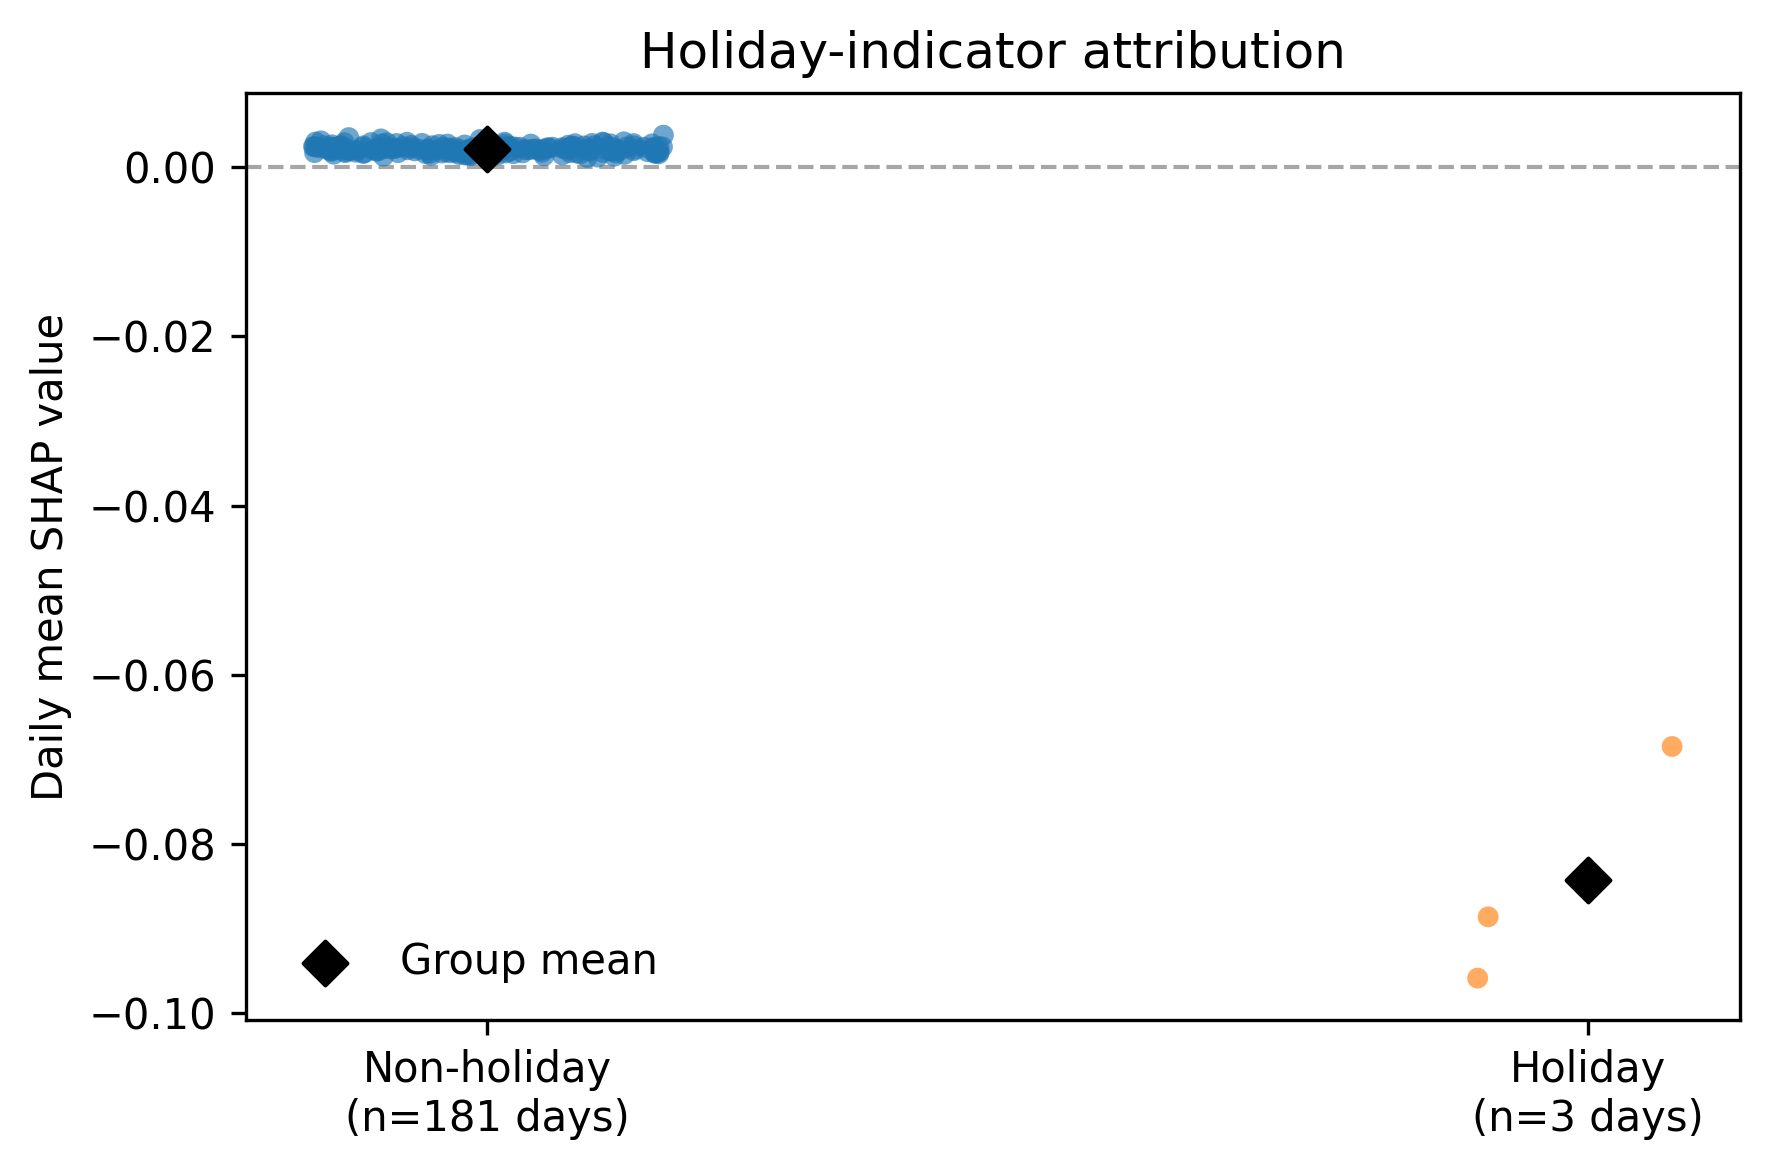

,count,mean,median,std
group,,,,
Non-holiday,181,0.002153,0.002120,0.000466
Holiday,3,-0.084303,-0.088601,0.014183


In [19]:
# SHAP attribution of the holiday indicator
holiday_idx = collapsed_names.index("holiday_not_sunday")

holiday_hourly = pd.DataFrame(
    {
        "holiday_shap": sv_c.values[:, holiday_idx],
        "is_holiday": (
            model_df.loc[ts_test, "holiday_not_sunday"]
            .astype(bool)
            .to_numpy()
        ),
    },
    index=ts_test,
)

# Verify that the indicator is constant within each calendar day
dates = holiday_hourly.index.normalize()
assert holiday_hourly.groupby(dates)["is_holiday"].nunique().max() == 1

# One observation per calendar day
holiday_daily = (
    holiday_hourly
    .assign(date=dates)
    .groupby("date", as_index=False)
    .agg(
        holiday_shap=("holiday_shap", "mean"),
        is_holiday=("is_holiday", "first"),
    )
)

holiday_daily["group"] = np.where(
    holiday_daily["is_holiday"],
    "Holiday",
    "Non-holiday",
)

order = ["Non-holiday", "Holiday"]
counts = holiday_daily["group"].value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(6, 4), dpi=300)

sns.stripplot(
    data=holiday_daily,
    x="group",
    y="holiday_shap",
    order=order,
    hue="group",
    palette={
        "Non-holiday": "tab:blue",
        "Holiday": "tab:orange",
    },
    jitter=0.16,
    alpha=0.65,
    size=5,
    legend=False,
    ax=ax,
)

# Add group means as black diamonds
group_means = (
    holiday_daily.groupby("group")["holiday_shap"]
    .mean()
    .reindex(order)
)

ax.scatter(
    range(len(order)),
    group_means,
    marker="D",
    s=55,
    color="black",
    label="Group mean",
    zorder=4,
)

ax.axhline(
    0,
    color="gray",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
)

ax.set_xticks(
    range(len(order)),
    [
        f"Non-holiday\n(n={counts['Non-holiday']} days)",
        f"Holiday\n(n={counts['Holiday']} days)",
    ],
)
ax.set_xlabel("")
ax.set_ylabel("Daily mean SHAP value")
ax.set_title("Holiday-indicator attribution")
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

display(
    holiday_daily.groupby("group")["holiday_shap"]
    .agg(["count", "mean", "median", "std"])
    .reindex(order)
)

#### Temporal contribution share

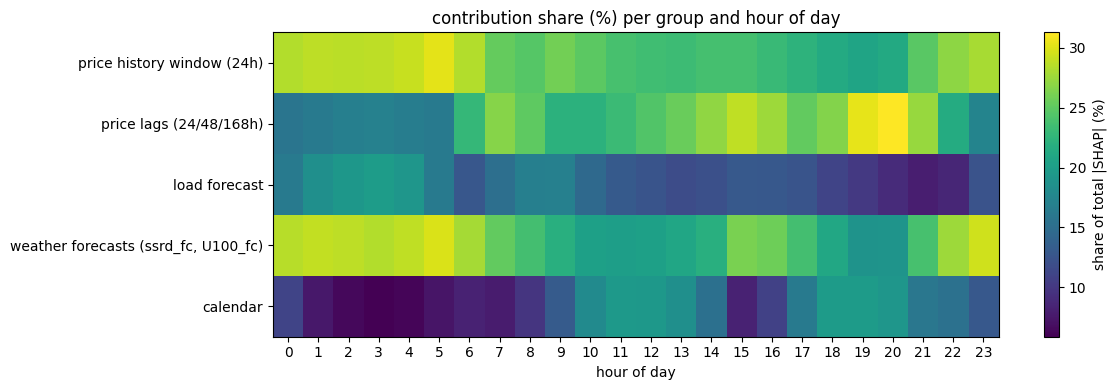

In [36]:
# Contributions are normalized per prediction (share of the total |SHAP|, in %)
# Shares are scale-free, so no asinh interpretation issue
total_abs = abs_c.sum(axis=1)
share = pd.DataFrame(index=ts_test)
for name, cols in groups.items():
    idx = [collapsed_names.index(c) for c in cols]
    share[name] = abs_c[:, idx].sum(axis=1) / total_abs * 100
share["hour"] = np.asarray(ts_test.hour)

# group share by hour of day: when does which driver matter?
by_hour = share.groupby("hour").mean()
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(by_hour.T, aspect="auto", cmap="viridis")
ax.set_xticks(range(24)); ax.set_xticklabels(by_hour.index)
ax.set_yticks(range(len(by_hour.columns))); ax.set_yticklabels(by_hour.columns)
ax.set_xlabel("hour of day"); ax.set_title("contribution share (%) per group and hour of day")
fig.colorbar(im, ax=ax, label="share of total |SHAP| (%)")
plt.tight_layout(); plt.show()

intraday trend
- The attribution share of `price lags` rises through the day and peaks in the evening (~19-20h), increasing from about 18% at night to about 37% around the evening price peak. Thus, price lags account for the largest attribution share during these hours.
- `weather forecast` shows a mild opposite trend: a bit higher at night, lower at midday (~10 pp swing).
- `price history window`, `load forecast` and `calendar` keep an almost flat share over all 24 hours.
- So the ordering of drivers is stable all day; only the price-lags / weather balance shifts.

### Local Importance

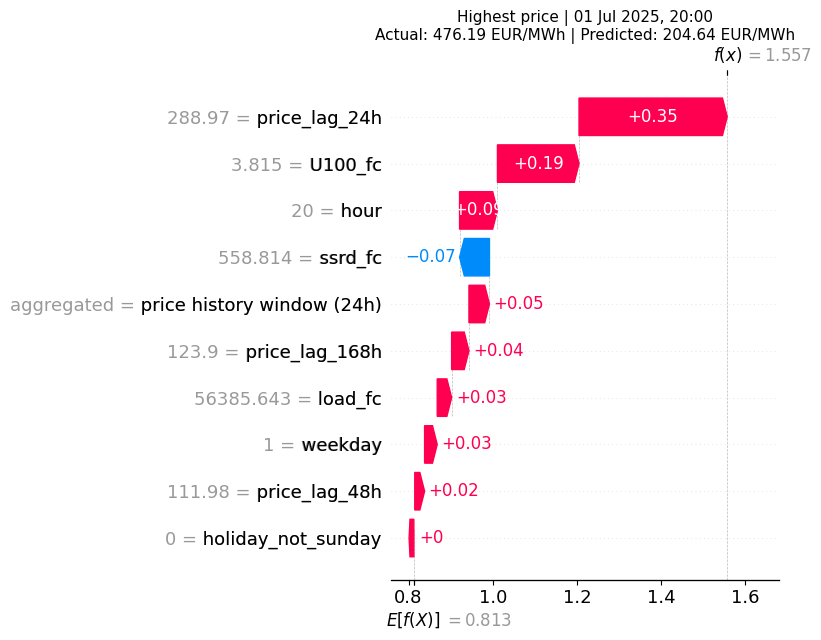

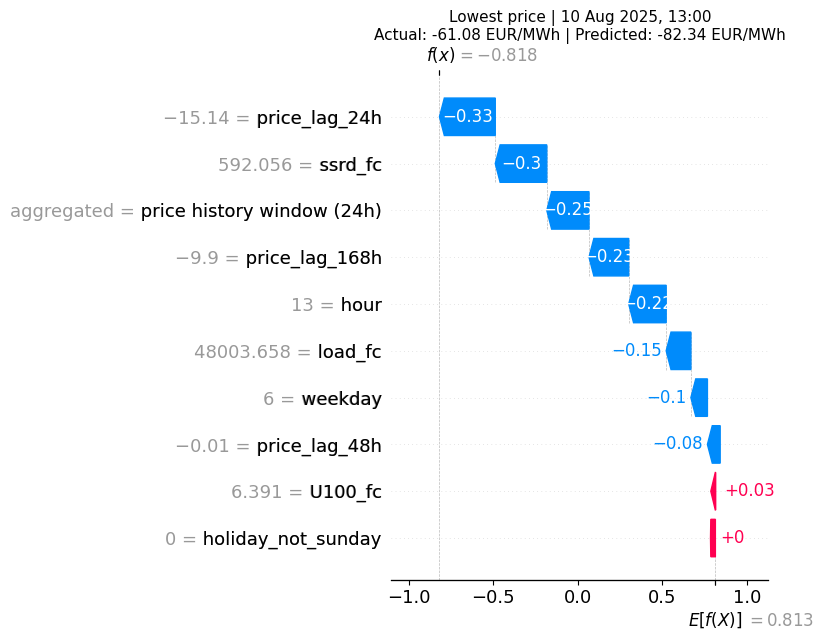

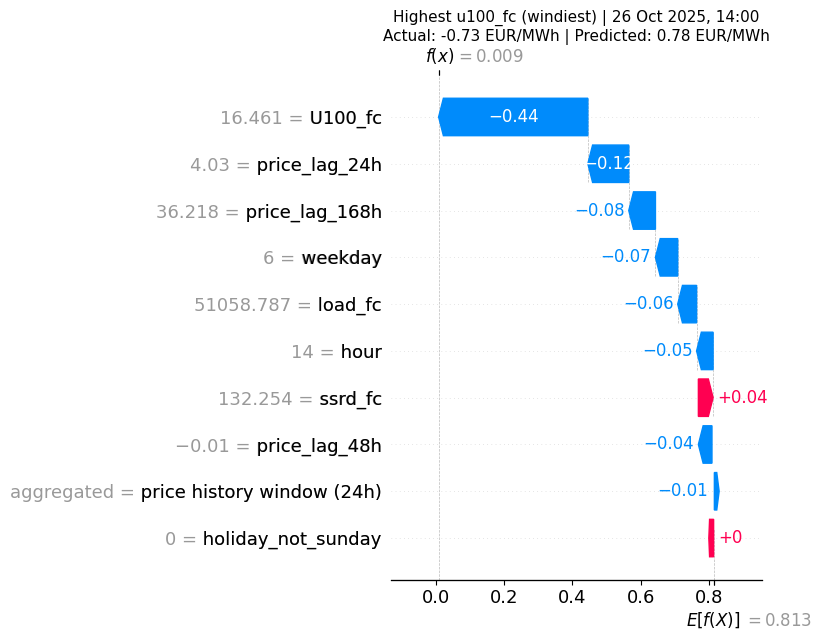

In [ ]:
# The 24 window hours are summed into one net "price history window" bar.

win_idx_c  = [collapsed_names.index(w) for w in window_names]
exo_idx    = [j for j, n in enumerate(collapsed_names) if n not in window_names]
grp_names  = [collapsed_names[j] for j in exo_idx] + [f"price history window ({XGB_LOOKBACK}h)"]
base_const = float(np.ravel(sv_c.base_values)[0])

def sv_local(i):
    vals = np.append(sv_c.values[i, exo_idx], sv_c.values[i, win_idx_c].sum())

    model_values = np.append(sv_c.data[i, exo_idx], np.nan)

    display_values = []

    for j in exo_idx:
        name = collapsed_names[j]

        if name == "hour":
            display_values.append(int(ts_test[i].hour))
        elif name == "weekday":
            display_values.append(int(ts_test[i].dayofweek))
        elif name == "holiday_not_sunday":
            display_values.append(int(model_df.loc[ts_test[i], name]))
        else:
            display_values.append(float(model_df.loc[ts_test[i], name]))

    display_values.append("aggregated")

    return shap.Explanation(
        values=vals,
        base_values=base_const,
        data=model_values,
        display_data=np.asarray(display_values, dtype=object),
        feature_names=grp_names,
    )

def show_local(i, label):
    pred_eur = float(asinh_inverse(pred_t[i], c_tv))
    timestamp = ts_test[i]

    ax = shap.plots.waterfall(
        sv_local(i),
        max_display=11,
        show=False,
    )

    ax.set_title(
        f"{label.capitalize()} | {timestamp:%d %b %Y, %H:%M}\n"
        f"Actual: {y_test[i]:.2f} EUR/MWh | "
        f"Predicted: {pred_eur:.2f} EUR/MWh",
        fontsize=11,
        pad=25,
    )

    plt.tight_layout()
    plt.show()

# --- Cases used in the thesis ---
show_local(int(np.argmax(y_test)), "highest price")
show_local(int(np.argmin(y_test)), "lowest price")
show_local(int(np.argmax(X_test["U100_fc"].to_numpy())),    "highest U100_fc (windiest)")

Price extremes
- Highest price (01.07, 20:00, 476.19 → 204.64): the evening and persistence features have positive SHAP contributions, but the model substantially underestimates the spike. The available features do not produce contributions large enough to reproduce this extreme price.
- Lowest price (10.08, 13:00, -61.08 → -82.34): high solar radiation and low recent prices have negative SHAP contributions, but the prediction is about 21 EUR/MWh below the observed price.

Windiest observation
- At the highest wind forecast, `U100_fc` has a strong negative SHAP contribution and dominates the local explanation; the observed price is close to zero.